# Thermodynamic analysis of cylinder pressure profile

### 1. Import packages and set input data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# ------------------------------------------------
# INPUT FILE
# ------------------------------------------------

folder_path = r"E:\Proj87-Universite_dOrleans_Ammonia-DME_Spark_Ignition\08-Experiments\01-Testbench_C8\01-Ammonia_DME\251009_1000rpm_Phi1i0_Tin45degC_DMEsweep_SparkTimingsweep\_python_results_20260408"
#folder_path = r"E:\Proj87-Universite_dOrleans_Ammonia-DME_Spark_Ignition\08-Experiments\01-Testbench_C8\01-Ammonia_DME\251016_1000rpm_Phi1i0_Tin45degC_DME0i02_SparkTimingSweep\_python_results_20260408"
#folder_path = r"E:\Proj87-Universite_dOrleans_Ammonia-DME_Spark_Ignition\08-Experiments\01-Testbench_C8\01-Ammonia_DME\251016_1000rpm_Phi1i0_Tin45degC_DME0i04_SparkTimingSweep\_python_results_20260408"
#folder_path = r"E:\Proj87-Universite_dOrleans_Ammonia-DME_Spark_Ignition\08-Experiments\01-Testbench_C8\01-Ammonia_DME\251016_1000rpm_Phi1i0_Tin45degC_DME0i06_SparkTimingSweep\_python_results_20260408"
#folder_path = r"E:\Proj87-Universite_dOrleans_Ammonia-DME_Spark_Ignition\08-Experiments\01-Testbench_C8\01-Ammonia_DME\251017_1000rpm_Phi1i0_Tin45degC_DME0i08_SparkTimingSweep\_python_results_20260408"
#folder_path = r"E:\Proj87-Universite_dOrleans_Ammonia-DME_Spark_Ignition\08-Experiments\01-Testbench_C8\01-Ammonia_DME\251017_1000rpm_Phi1i0_Tin45degC_DME0i1_SparkTimingSweep\_python_results_20260408"
#folder_path = r"E:\Proj87-Universite_dOrleans_Ammonia-DME_Spark_Ignition\08-Experiments\01-Testbench_C8\01-Ammonia_DME\251020_1000rpm_Phi0i9_Tin45degC_SparkTimingSweep\_python_results_20260408"
#folder_path = r"E:\Proj87-Universite_dOrleans_Ammonia-DME_Spark_Ignition\08-Experiments\01-Testbench_C8\01-Ammonia_DME\251020_1000rpm_Phi0i9_Tin45degC_DME0i02_SparkTimingSweep\_python_results_20260408"
#folder_path = r"E:\Proj87-Universite_dOrleans_Ammonia-DME_Spark_Ignition\08-Experiments\01-Testbench_C8\01-Ammonia_DME\251020_1000rpm_Phi0i9_Tin45degC_DME0i04_SparkTimingSweep\_python_results_20260408"
#folder_path = r"E:\Proj87-Universite_dOrleans_Ammonia-DME_Spark_Ignition\08-Experiments\01-Testbench_C8\01-Ammonia_DME\251021_1000rpm_Phi0i9_Tin45degC_DME0i06_SparkTimingSweep\_python_results_20260408"
#folder_path = r"E:\Proj87-Universite_dOrleans_Ammonia-DME_Spark_Ignition\08-Experiments\01-Testbench_C8\01-Ammonia_DME\251022_1000rpm_Phi0i9_Tin45degC_DME0i08_SparkTimingSweep\_python_results_20260408"
#folder_path = r"E:\Proj87-Universite_dOrleans_Ammonia-DME_Spark_Ignition\08-Experiments\01-Testbench_C8\01-Ammonia_DME\251023_1000rpm_Phi0i9_Tin45degC_DME0i1_SparkTimingSweep\_python_results_20260408"
#folder_path = r"E:\Proj87-Universite_dOrleans_Ammonia-DME_Spark_Ignition\08-Experiments\01-Testbench_C8\01-Ammonia_DME\251023_1000rpm_Phi0i8_Tin45degC_SparkTimingSweep\_python_results"
#folder_path = r"E:\Proj87-Universite_dOrleans_Ammonia-DME_Spark_Ignition\08-Experiments\01-Testbench_C8\01-Ammonia_DME\251023_1000rpm_Phi0i8_Tin45degC_DME0i02_SparkTimingSweep\_python_results"
#folder_path = r"E:\Proj87-Universite_dOrleans_Ammonia-DME_Spark_Ignition\08-Experiments\01-Testbench_C8\01-Ammonia_DME\251024_1000rpm_Phi0i8_Tin45degC_DME0i04_SparkTimingSweep\_python_results"
#folder_path = r"E:\Proj87-Universite_dOrleans_Ammonia-DME_Spark_Ignition\08-Experiments\01-Testbench_C8\01-Ammonia_DME\251024_1000rpm_Phi0i8_Tin45degC_DME0i06_SparkTimingSweep\_python_results"
#folder_path = r"E:\Proj87-Universite_dOrleans_Ammonia-DME_Spark_Ignition\08-Experiments\01-Testbench_C8\01-Ammonia_DME\251028_1000rpm_Phi0i8_Tin45degC_DME0i08_SparkTimingSweep\_python_results"
#folder_path = r"E:\Proj87-Universite_dOrleans_Ammonia-DME_Spark_Ignition\08-Experiments\01-Testbench_C8\01-Ammonia_DME\251028_1000rpm_Phi0i8_Tin45degC_DME0i1_SparkTimingSweep\_python_results"
#folder_path = r"E:\Proj87-Universite_dOrleans_Ammonia-DME_Spark_Ignition\08-Experiments\01-Testbench_C8\01-Ammonia_DME\251028_1000rpm_Phi0i7_Tin45degC_DME0i08_SparkTimingSweep\_python_results"
#folder_path = r"E:\Proj87-Universite_dOrleans_Ammonia-DME_Spark_Ignition\08-Experiments\01-Testbench_C8\01-Ammonia_DME\251028_1000rpm_Phi0i7_Tin45degC_DME0i1_SparkTimingSweep\_python_results"
file_path = r"AR_MT_251009_15h40m08s_13696.txt"
#file_path = r"AR_MT_251009_15h43m17s_13697.txt"
#file_path = r"AR_MT_251009_15h47m58s_13699.txt"
#file_path = r"AR_MT_251009_15h53m39s_13700.txt"
#file_path = r"AR_MT_251016_14h09m07s_13547.txt"
#file_path = r"AR_MT_251016_12h12m41s_13538.txt"
#file_path = r"AR_MT_251016_12h15m42s_13539.txt"
#file_path = r"AR_MT_251016_12h19m05s_13540.txt"
#file_path = r"AR_MT_251016_12h22m20s_13541.txt"
#file_path = r"AR_MT_251016_12h38m12s_13542.txt"
#file_path = r"AR_MT_251016_12h41m04s_13543.txt"
#file_path = r"AR_MT_251016_13h18m09s_13545.txt"
#file_path = r"AR_MT_251016_14h32m34s_13549.txt"
#file_path = r"AR_MT_251016_15h20m03s_13551.txt"
#file_path = r"AR_MT_251016_15h24m16s_13552.txt"
#file_path = r"AR_MT_251016_15h26m18s_13553.txt"
#file_path = r"AR_MT_251016_16h03m31s_13554.txt"
#file_path = r"AR_MT_251016_16h06m42s_13555.txt"
#file_path = r"AR_MT_251016_16h09m40s_13556.txt"
#file_path = r"AR_MT_251016_16h51m53s_13557.txt"
#file_path = r"AR_MT_251016_16h54m57s_13558.txt"
#file_path = r"AR_MT_251016_16h58m27s_13559.txt"
#file_path = r"AR_MT_251016_17h01m42s_13560.txt"
#file_path = r"AR_MT_251016_17h27m30s_13562.txt"
#file_path = r"AR_MT_251016_17h30m33s_13563.txt"
#file_path = r"AR_MT_251016_17h33m40s_13564.txt"
#file_path = r"AR_MT_251016_17h36m13s_13565.txt"
#file_path = r"AR_MT_251017_11h31m56s_13542.txt"
#file_path = r"AR_MT_251017_11h05m58s_13536.txt"
#file_path = r"AR_MT_251017_11h10m05s_13537.txt"
#file_path = r"AR_MT_251017_11h14m00s_13538.txt"
#file_path = r"AR_MT_251017_11h17m35s_13539.txt"
#file_path = r"AR_MT_251017_11h23m41s_13540.txt"
#file_path = r"AR_MT_251017_11h28m24s_13541.txt"
#file_path = r"AR_MT_251017_13h36m40s_13547.txt"
#file_path = r"AR_MT_251017_13h32m54s_13546.txt"
#file_path = r"AR_MT_251017_12h20m53s_13545.txt"
#file_path = r"AR_MT_251017_12h10m14s_13543.txt"
#file_path = r"AR_MT_251017_12h13m40s_13544.txt"
#file_path = r"AR_MT_251020_14h07m43s_13554.txt"
#file_path = r"AR_MT_251020_14h12m06s_13555.txt"
#file_path = r"AR_MT_251020_14h39m40s_13558.txt"
#file_path = r"AR_MT_251020_14h43m27s_13559.txt"
#file_path = r"AR_MT_251020_15h24m25s_13560.txt"
#file_path = r"AR_MT_251020_15h27m39s_13561.txt"
#file_path = r"AR_MT_251020_15h30m58s_13562.txt"
#file_path = r"AR_MT_251020_16h27m55s_13564.txt"
#file_path = r"AR_MT_251020_16h31m29s_13565.txt"
#file_path = r"AR_MT_251020_16h35m46s_13566.txt"
#file_path = r"AR_MT_251020_16h39m03s_13567.txt"
#file_path = r"AR_MT_251020_16h45m05s_13568.txt"
#file_path = r"AR_MT_251020_17h15m53s_13570.txt"
#file_path = r"AR_MT_251020_17h19m35s_13571.txt"
#file_path = r"AR_MT_251021_11h18m51s_13576.txt"
#file_path = r"AR_MT_251021_11h23m21s_13577.txt"
#file_path = r"AR_MT_251021_11h31m42s_13578.txt"
#file_path = r"AR_MT_251021_12h58m04s_13580.txt"
#file_path = r"AR_MT_251021_13h03m59s_13581.txt"
#file_path = r"AR_MT_251021_13h49m22s_13583.txt"
#file_path = r"AR_MT_251021_13h54m35s_13584.txt"
#file_path = r"AR_MT_251021_14h33m38s_13585.txt"
#file_path = r"AR_MT_251021_15h23m16s_13586.txt"
#file_path = r"AR_MT_251021_15h30m07s_13587.txt"
#file_path = r"AR_MT_251021_16h19m08s_13588.txt"
#file_path = r"AR_MT_251021_16h25m04s_13589.txt"
#file_path = r"AR_MT_251021_17h02m10s_13591.txt"
#file_path = r"AR_MT_251021_17h31m59s_13593.txt"
#file_path = r"AR_MT_251021_17h37m20s_13594.txt"
#file_path = r"AR_MT_251021_18h01m10s_13596.txt"
#file_path = r"AR_MT_251021_18h05m29s_13597.txt"
#file_path = r"AR_MT_251022_13h39m09s_13542.txt"
#file_path = r"AR_MT_251022_13h43m48s_13543.txt"
#file_path = r"AR_MT_251022_14h18m22s_13546.txt"
#file_path = r"AR_MT_251022_14h23m11s_13547.txt"
#file_path = r"AR_MT_251022_15h04m39s_13549.txt"
#file_path = r"AR_MT_251023_12h25m25s_13559.txt"
#file_path = r"AR_MT_251023_12h30m10s_13560.txt"
#file_path = r"AR_MT_251023_12h40m35s_13561.txt"
#file_path = r"AR_MT_251023_13h36m48s_13564.txt"
#file_path = r"AR_MT_251024_11h25m06s_13541.txt"
#file_path = r"AR_MT_251024_13h57m16s_13553.txt"
#file_path = r"AR_MT_251028_12h52m59s_13572.txt"
#file_path = r"AR_MT_251028_13h08m34s_13574.txt"
#file_path = r"AR_MT_251028_15h58m38s_13578.txt"
#file_path = r"AR_MT_251028_16h41m51s_13581.txt"
emission_file = r"emission_output.txt"
performance_file = r"performance_output.txt"

# ------------------------------------------------
# UNIVERSAL PARAMETERS
# ------------------------------------------------

R = 287
Ru = 8.314462618

# ------------------------------------------------
# ENGINE PARAMETERS
# ------------------------------------------------

# geometry
bore = 0.085
stroke = 0.088
conrod = 0.145
compression_ratio = 14.23

# operating conditions
rpm = 1000
Spark_timing = -36
#Spark_timing = -38
#Spark_timing = -40
#Spark_timing = -42
#Spark_timing = -28
#Spark_timing = -30
#Spark_timing = -32
#Spark_timing = -34
#Spark_timing = -36
#Spark_timing = -38
#Spark_timing = -40
#Spark_timing = -42
#Spark_timing = -28
#Spark_timing = -32
#Spark_timing = -34
#Spark_timing = -36
#Spark_timing = -38
#Spark_timing = -40
#Spark_timing = -42
#Spark_timing = -28
#Spark_timing = -30
#Spark_timing = -32
#Spark_timing = -34
#Spark_timing = -36
#Spark_timing = -38
#Spark_timing = -40
#Spark_timing = -42
#Spark_timing = -22
#Spark_timing = -24
#Spark_timing = -26
#Spark_timing = -28
#Spark_timing = -30
#Spark_timing = -32
#Spark_timing = -34
#Spark_timing = -12
#Spark_timing = -14
#Spark_timing = -16
#Spark_timing = -18
#Spark_timing = -20
#Spark_timing = -38
#Spark_timing = -40
#Spark_timing = -42
#Spark_timing = -44
#Spark_timing = -30
#Spark_timing = -32
#Spark_timing = -34
#Spark_timing = -36
#Spark_timing = -38
#Spark_timing = -40
#Spark_timing = -42
#Spark_timing = -44
#Spark_timing = -26
#Spark_timing = -28
#Spark_timing = -30
#Spark_timing = -32
#Spark_timing = -34
#Spark_timing = -36
#Spark_timing = -38
#Spark_timing = -40
#Spark_timing = -42
#Spark_timing = -44
#Spark_timing = -26
#Spark_timing = -28
#Spark_timing = -30
#Spark_timing = -32
#Spark_timing = -34
#Spark_timing = -36
#Spark_timing = -38
#Spark_timing = -40
#Spark_timing = -42
#Spark_timing = -26
#Spark_timing = -28
#Spark_timing = -30
#Spark_timing = -32
#Spark_timing = -34
#Spark_timing = -16
Spark_timing = -18
Twall = 450
IVC = -122
EVO = 149

# ------------------------------------------------
# STANDARD CONDITIONS
# ------------------------------------------------

# Pa
p_std = 101325

# K
T_std = 273.15

# ------------------------------------------------
# GAS COMPOSITION
# ------------------------------------------------

# mole fraction
x_N2 = 0.79
x_O2 = 0.21

# molar weights (kg/mol)
M_N2 = 28.0134e-3
M_O2 = 31.9988e-3

# ------------------------------------------------
# FUEL COMPOSITION
# ------------------------------------------------

# mole fraction
#x_NH3 = 1
#x_DME = 0
#x_NH3 = 0.98
#x_DME = 0.02
#x_NH3 = 0.96
#x_DME = 0.04
#x_NH3 = 0.94
#x_DME = 0.06
#x_NH3 = 0.92
#x_DME = 0.08
x_NH3 = 0.9
x_DME = 0.1

# molar weights (kg/mol)
M_NH3 = 17.03052e-3
M_DME = 46.06844e-3
M_H2 = 2.016000e-3
M_CO  = 28.01000e-3
M_H2O = 18.0153e-3
M_CO2 = 44.0095e-3

# lower heating values (J/kg)
LHV_NH3 = 18.6e6
LHV_DME = 28.4e6
LHV_H2 = 120.0e6
LHV_CO  = 10.1e6

# ------------------------------------------------
# WOSCHNI HEAT TRANSFER MODEL PARAMETERS
# ------------------------------------------------

C1 = 2.28
C2 = 0.00322

### 2. Read input files

In [404]:
# ------------------------------------------------
# READ PERFORMANCE DATA
# ------------------------------------------------

with open(folder_path + "\\" + "performance_output.txt","r") as f:

    header = f.readline().strip().split()

    idx_air = header.index("Air[Nl/min]")
    idx_fuel_nh3 = header.index("NH3[Nl/min]")
    idx_fuel_dme = header.index("DME[Nl/min]")

    air_flow_Lmin = None
    nh3_flow_Lmin = None
    dme_flow_Lmin = None

    for line in f:

        parts = line.split()

        if float(parts[0]) == Spark_timing:

            air_flow_Lmin = float(parts[idx_air])
            nh3_flow_Lmin = float(parts[idx_fuel_nh3])
            dme_flow_Lmin = float(parts[idx_fuel_dme])

            break

# ------------------------------------------------
# READ EMISSION DATA
# ------------------------------------------------

with open(folder_path + "\\" + "emission_output.txt","r") as f:

    header = f.readline().strip().split()

    idx_CO = header.index("CO[vol-ppm]")
    idx_NH3 = header.index("NH3[vol-ppm]")
    idx_CH2O = header.index("CH2O[vol-ppm]")
    idx_CH3CHO = header.index("CH3CHO[vol-ppm]")

    X_CO_exhaust = None
    X_NH3_exhaust = None
    X_CH2O_exhaust = None
    X_CH3CHO_exhaust = None

    for line in f:

        parts = line.split()

        if float(parts[0]) == Spark_timing:

            X_CO_exhaust = float(parts[idx_CO])
            X_NH3_exhaust = float(parts[idx_NH3])
            X_CH2O_exhaust = float(parts[idx_CH2O])
            X_CH3CHO_exhaust = float(parts[idx_CH3CHO])

            break

# ------------------------------------------------
# CONVERT TO FRACTIONS
# ------------------------------------------------

X_CO_exhaust = X_CO_exhaust * 1e-6
X_NH3_exhaust = X_NH3_exhaust * 1e-6
X_CH2O_exhaust = X_CH2O_exhaust * 1e-6
X_CH3CHO_exhaust = X_CH3CHO_exhaust * 1e-6

# ------------------------------------------------
# SANITY CHECK FOR OXYGENATES
# ------------------------------------------------

if (X_CH2O_exhaust + X_CH3CHO_exhaust) > X_NH3_exhaust:

    print("The mole fraction of unburned oxygenates is too high")

    X_CH2O_exhaust = 0.0
    X_CH3CHO_exhaust = 0.0

# ------------------------------------------------
# LOAD PRESSURE TRACE
# ------------------------------------------------

file_prefix = file_path.replace(".txt", "")
data = pd.read_csv(folder_path + "\\" + file_path, sep='\s+')

theta = data["CAD[deg]"].values
p_cyl = data["p_cyl[bar]"].values*1e5
p_intake = data["p_intake[bar]"].values*1e5



The mole fraction of unburned oxygenates is too high


### 3. Calculations

In [405]:
# ------------------------------------------------
# CYLINDER VOLUME
# ------------------------------------------------

def cylinder_volume(theta):

    # deg -> rad
    th = np.radians(theta)

    # instantaneous stroke
    x = r*(1-np.cos(th)) + (l - np.sqrt(l**2-(r*np.sin(th))**2))

    return Vc + area*x

# ------------------------------------------------
# CYLINDER AREA
# ------------------------------------------------

def cylinder_area(theta):

    # deg -> rad
    th = np.radians(theta)

    # instantaneous stroke
    x = r*(1-np.cos(th)) + (l - np.sqrt(l**2-(r*np.sin(th))**2))

    return 2*area + np.pi*bore*x

# ------------------------------------------------
# GAMMA FUNCTION
# ------------------------------------------------

def gamma_T(T):

    # correlation funtion
    g = 1.38 - 0.0001*(T-300)

    return np.clip(g,1.25,1.40)

# ------------------------------------------------
# EXTENDED WOSCHNI HEAT TRANSFER
# ------------------------------------------------

def woschni_ht(theta,area,p,T,V,p_mot,C0):

    B = bore
    Vd = Vs

    # mean piston speed (m/s)
    Cm = 2*stroke*rpm/60

    # initialize heat transfer rate vector
    Qdeg = np.zeros_like(theta)

    for i in range(len(theta)):

        # base gas velocity (m/s)
        w = C1 * Cm

        # combustion contribution only during combustion
        if Spark_timing <= theta[i] <= EVO:
            
            # pressure difference
            dp = max(p[i] - p_mot[i],0)
            w += C2 * (Vd * T[i] / (p[i] * V[i])) * dp

        # Woschni function
        h = C0 * (B**-0.2) * (p[i]/1000)**0.8 * (T[i]**-0.53) * (w**0.8)

        # heat transfer rate (J/s)
        Qdot = h * area[i] * (T[i] - Twall)

        # J/s -> J/deg
        Qdeg[i] = Qdot / (6*rpm)

    return Qdeg

# ------------------------------------------------
# OPTIMIZE C0
# ------------------------------------------------

def optimize_C0(theta,p,T,V,p_mot,HRR_app,comb_eff):

    # mask crank angle range between spark timing and EVO
    mask = (theta>=Spark_timing) & (theta<=EVO)

    # mask crank angle and heat release rate vectors
    theta_c = theta[mask]
    HRR_c = HRR_app[mask]

    # energy at EVO
    target_energy = LHV_fuel*fuel_mass_cycle*comb_eff

    # start values
    best_C0 = 3.26
    best_error = 1e30

    # optimize C0 between 0.5 and 30
    for C0 in np.linspace(0.5,30.0,600):

        # evaluate Woschni function
        Qw = woschni_ht(theta,A,p,T,V,p_mot,C0)

        # mask heat transfer rate
        Qw_c = Qw[mask]

        # cumulate heat release and heat transfer
        released = np.trapz(HRR_c,theta_c)
        heatloss = np.trapz(Qw_c,theta_c)

        # sum of heat release and heat transfer
        energy = released + heatloss

        # evaluate absolute error
        error = abs(energy-target_energy)

        if error < best_error:

            best_error = error
            best_C0 = C0

    print("Energy at EVO:",target_energy,"J")
    print("Error:",best_error,"J")
    print("Optimized C0:",best_C0)

    return best_C0

# ------------------------------------------------
# MOTORED PRESSURE FIT
# ------------------------------------------------

def calculate_motored_pressure(theta, p, V, IVC, Spark_timing):

    # determine IVC
    idx_ivc = np.argmin(np.abs(theta-IVC))

    # pressure and volume at IVC
    p_ivc = p[idx_ivc]
    V_ivc = V[idx_ivc]

    # define mask criteria
    mask = (theta >= IVC) & (theta <= Spark_timing)

    # motored pressure and volume
    p_fit = p[mask]
    V_fit = V[mask]

    # start values
    best_n = 1.3
    best_error = 1e30

    # search polytropic exponent
    for n in np.linspace(1.20,1.40,200):

        # determine motored pressure
        p_model = p_ivc*(V_ivc/V_fit)**n

        # evaluate squared error
        error = np.mean((p_fit-p_model)**2)

        if error < best_error:

            best_error = error
            best_n = n

    print("Best polytropic exponent:",best_n)

    # compute full motored curve
    p_mot = p_ivc*(V_ivc/V)**best_n

    return p_mot

# ------------------------------------------------
# COMBUSTION PHASING
# ------------------------------------------------

def find_CA(target):
    idx = np.where(CHR_norm >= target)[0][0]
    return theta[idx]

# ------------------------------------------------
# STOICHIOMETRIC AIR-FUEL RATIO
# ------------------------------------------------

def calculate_AFR_st(x_NH3, x_DME, M_air, M_fuel):

    # O2 requirement per mol fuel
    nu_O2 = x_NH3 * 0.75 + x_DME * 3.0

    # air requirement (21% O2)
    nu_air = nu_O2 / 0.21

    # mass-based AFR
    AFR_st = (nu_air * M_air) / M_fuel

    return AFR_st

# ------------------------------------------------
# EXHAUST MOLAR MASS (LEAN + RICH COMBINED)
# ------------------------------------------------

def M_exhaust_lambda_mix(lam, x_NH3, x_DME):

    # stoichiometric O2 demand per mol fuel mixture
    nu_O2_stoich = 0.75*x_NH3 + 3.0*x_DME

    # ------------------------------------------------
    # LEAN CASE (λ ≥ 1)
    # ------------------------------------------------
    if lam >= 1.0:

        n_N2  = 0.5*x_NH3 + 3.76 * lam * nu_O2_stoich
        n_H2O = 1.5*x_NH3 + 3.0*x_DME
        n_CO2 = 2.0*x_DME
        n_O2  = (lam - 1.0) * nu_O2_stoich

        n_tot = n_N2 + n_H2O + n_CO2 + n_O2

        m_tot = (
            n_N2*M_N2 +
            n_H2O*M_H2O +
            n_CO2*M_CO2 +
            n_O2*M_O2
        )

    # ------------------------------------------------
    # RICH CASE (λ < 1)
    # ------------------------------------------------
    else:

        # available oxygen
        nu_O2_avail = lam * nu_O2_stoich

        # burned fraction (simple approximation)
        f = lam

        # species formation
        n_N2 = 0.5*x_NH3*f + 3.76*nu_O2_avail
        n_H2O = 1.5*x_NH3*f + 3.0*x_DME*f
        n_CO = 2.0*x_DME*f

        # unburned fuel
        n_NH3 = x_NH3*(1.0 - f)
        n_DME = x_DME*(1.0 - f)

        n_tot = n_N2 + n_H2O + n_CO + n_NH3 + n_DME

        m_tot = (
            n_N2*M_N2 +
            n_H2O*M_H2O +
            n_CO*M_CO +
            n_NH3*M_NH3 +
            n_DME*M_DME
        )

    return m_tot / n_tot

# ------------------------------------------------
# AIR COMPOSITION
# ------------------------------------------------

M_air = x_N2*M_N2 + x_O2*M_O2

rho_air = p_std*M_air/(Ru*T_std)

# ------------------------------------------------
# FUEL COMPOSITION
# ------------------------------------------------

M_fuel = x_NH3*M_NH3 + x_DME*M_DME

# mass fractions

w_NH3 = x_NH3*M_NH3/M_fuel
w_DME = x_DME*M_DME/M_fuel

# lower heating values

LHV_fuel = w_NH3*LHV_NH3 + w_DME*LHV_DME

# fuel density at standard conditions

rho_fuel = p_std*M_fuel/(Ru*T_std)

print("Fuel molar mass:",M_fuel,"kg/mol")
print("Fuel LHV:",LHV_fuel/1e6,"MJ/kg")

# ------------------------------------------------
# VOLUME FLOW INPUT (L/min)
# ------------------------------------------------

fuel_flow_Lmin = nh3_flow_Lmin + dme_flow_Lmin

# ------------------------------------------------
# FLOW CONVERSION
# ------------------------------------------------

air_flow_m3s = air_flow_Lmin/1000/60
fuel_flow_m3s = fuel_flow_Lmin/1000/60

air_mdot = rho_air*air_flow_m3s
fuel_mdot = rho_fuel*fuel_flow_m3s

# ------------------------------------------------
# MASS PER ENGINE CYCLE
# ------------------------------------------------

rev_per_sec = rpm/60
cycles_per_sec = rev_per_sec/2

air_mass_cycle = air_mdot/cycles_per_sec
fuel_mass_cycle = fuel_mdot/cycles_per_sec

m_total = air_mass_cycle + fuel_mass_cycle

fuel_energy = fuel_mass_cycle*LHV_fuel

print("Air mass per cycle:",air_mass_cycle,"kg")
print("Fuel mass per cycle:",fuel_mass_cycle,"kg")
print("Fuel energy per cycle:",fuel_energy,"J")

# ------------------------------------------------
# AIR-FUEL RATIO
# ------------------------------------------------

AFR_st = calculate_AFR_st(x_NH3, x_DME, M_air, M_fuel)

print("Stoichiometric AFR:", AFR_st)

lambda_global = (air_mass_cycle / fuel_mass_cycle) / AFR_st

print("Lambda:", lambda_global)

# ------------------------------------------------
# EXHAUST MEAN MOLAR WEIGHT
# ------------------------------------------------

Mean_molar_weight_exhaust = M_exhaust_lambda_mix(lambda_global, x_NH3, x_DME)

print("Exhaust mean molar weight:", Mean_molar_weight_exhaust,"kg/mol")

# ------------------------------------------------
# EXHAUST MASS FLOW RATE
# ------------------------------------------------

exhaust_mdot = air_mdot + fuel_mdot

# ------------------------------------------------
# GEOMETRY
# ------------------------------------------------

area = np.pi*(bore/2)**2
r = stroke/2
l = conrod

Vs = area*stroke
Vc = Vs/(compression_ratio-1)

# ------------------------------------------------
# PRESSURE PEGGING
# ------------------------------------------------

# define mask criteria
mask = (theta>-180)&(theta<IVC)

# calculate pressure offset
offset = np.mean(p_intake[mask]) - np.mean(p_cyl[mask])

# peg cylinder pressure
p = p_cyl + offset

print("Pressure offset:", offset/1e5, "bar")

# ------------------------------------------------
# FILTER PRESSURE
# ------------------------------------------------

p = savgol_filter(p,21,3)

# ------------------------------------------------
# CYLINDER VOLUME
# ------------------------------------------------

V = cylinder_volume(theta)

# ------------------------------------------------
# CYLINDER AREA
# ------------------------------------------------

A = cylinder_area(theta)

# ------------------------------------------------
# TEMPERATURE AT IVC
# ------------------------------------------------

# determine IVC
idx = np.argmin(np.abs(theta-IVC))

# calculate temperature according to ideal gas law
T_ivc = p[idx]*V[idx]/(m_total*R)

print("Temperature at IVC:",T_ivc,"K")

# ------------------------------------------------
# MOTORED PRESSURE
# ------------------------------------------------

p_mot = calculate_motored_pressure(theta,p,V,IVC,Spark_timing)

# ------------------------------------------------
# ITERATIVE HEAT RELEASE SOLVER
# ------------------------------------------------

gamma = np.ones(len(theta))*1.35

for i in range(5):

    # pressure gradient
    dp = np.gradient(p,theta)
    # volume gradient
    dV = np.gradient(V,theta)

    # apparent rate of heat release
    HRR_app = (gamma/(gamma-1))*p*dV + (1/(gamma-1))*V*dp

    # temperature
    T = p*V/(m_total*R)

    # heat capacity ratio
    gamma = gamma_T(T)

# ------------------------------------------------
# IMEP
# ------------------------------------------------

# work
work = np.trapz(p, V)

# IMEP
IMEP = work / Vs

print("IMEP:", IMEP/1e5, "bar")

# ------------------------------------------------
# Thermal efficiency
# ------------------------------------------------

eta_therm = (IMEP*Vs)/(LHV_fuel*fuel_mass_cycle)*100

print("Thermal efficiency:",eta_therm,"%")

# ------------------------------------------------
# MOLE FRACTION → MASS FRACTION
# ------------------------------------------------

Y_H2 = 0.02 * M_H2 / Mean_molar_weight_exhaust

Y_CO = X_CO_exhaust * M_CO / Mean_molar_weight_exhaust

Y_NH3 = X_NH3_exhaust * M_NH3 / Mean_molar_weight_exhaust

Y_oxygenates = (X_CH2O_exhaust + X_CH3CHO_exhaust) * M_DME / Mean_molar_weight_exhaust

# ------------------------------------------------
# MASS FLOW OF SPECIES
# ------------------------------------------------

m_H2 = Y_H2 * exhaust_mdot

m_CO = Y_CO * exhaust_mdot

m_NH3 = Y_NH3 * exhaust_mdot

m_oxygenates = Y_oxygenates * exhaust_mdot

# ------------------------------------------------
# COMBUSTION EFFICIENCY
# ------------------------------------------------

#energy of H2
loss_H2 = m_H2 * LHV_H2

# energy of CO
loss_CO = m_CO * LHV_CO

# energy of unburned NH3
loss_NH3 = m_NH3 * LHV_NH3

# energy of oxygenated hydrocarbons
loss_oxygenates = m_oxygenates * LHV_DME

# energy of exhaust
chemical_loss = loss_H2 + loss_CO + loss_NH3 + loss_oxygenates

# combustion efficiency
combustion_efficiency = 1 - chemical_loss / (fuel_mdot * LHV_fuel)

#combustion_efficiency_mole = 1 - (LHV_H2 * M_H2 * 0.02 + LHV_CO * M_CO * X_CO_exhaust + LHV_NH3 * M_NH3 * X_NH3_exhaust + LHV_DME * M_DME * (X_CH2O_exhaust + X_CH3CHO_exhaust)) / (LHV_NH3 * x_NH3 + LHV_DME * x_DME)

# combustion efficiency

print("Combustion efficiency (mass-based):", combustion_efficiency)

# ------------------------------------------------
# OPTIMIZE HEAT TRANSFER PARAMETER
# ------------------------------------------------

C0 = optimize_C0(theta,p,T,V,p_mot,HRR_app,combustion_efficiency)

# compute final heat transfer
Qw = woschni_ht(theta,A,p,T,V,p_mot,C0)

# ------------------------------------------------
# TOTAL HEAT RELEASE RATE
# ------------------------------------------------

HRR_total = HRR_app + Qw

# ------------------------------------------------
# CUMULATED HEAT RELEASE
# ------------------------------------------------

# cumulated heat release
CHR = np.cumsum(HRR_app*np.gradient(theta))

# normalize cumulated heat release
CHR_norm = (CHR - np.min(CHR)) / (np.max(CHR) - np.min(CHR))

# cumulated heat release
CHR_total = np.cumsum(HRR_total*np.gradient(theta))

# cumulated heat transfer
CQw = np.cumsum(Qw*np.gradient(theta))

# ------------------------------------------------
# COMBUSTION PHASING
# ------------------------------------------------

CA10 = find_CA(0.10)
CA50 = find_CA(0.50)
CA90 = find_CA(0.90)
print("CA10 =", CA10, "deg")
print("CA50 =", CA50, "deg")
print("CA90 =", CA90, "deg")


Fuel molar mass: 0.019934312000000003 kg/mol
Fuel LHV: 20.864792042985982 MJ/kg
Air mass per cycle: 0.0003903231271054948 kg
Fuel mass per cycle: 5.225760221388973e-05 kg
Fuel energy per cycle: 1090.3440028578932 J
Stoichiometric AFR: 6.719468386253525
Lambda: 1.1115778669745788
Exhaust mean molar weight: 0.026029376064378832 kg/mol
Pressure offset: -0.05492492227979281 bar
Temperature at IVC: 386.9172809095239 K
Best polytropic exponent: 1.3618090452261307
IMEP: 6.951212978131701 bar
Thermal efficiency: 31.83519107177897 %
Combustion efficiency (mass-based): 0.9126289939815668
Energy at EVO: 995.0795504220337 J
Error: 1.337289567757125 J
Optimized C0: 4.784641068447412
CA10 = 6.5 deg
CA50 = 17.4 deg
CA90 = 31.1 deg


### 4. save the results

In [406]:
# ------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------

out = np.column_stack([

theta,
p,
p_mot,
gamma,
T,
HRR_app,
HRR_total,
Qw,
CHR,
CHR_total,
CQw,
CHR_norm

])

header = "CAD[deg]\tp_filtered[Pa]\tp_motored[Pa]\tgamma[-]\tT[K]\tHRR_app[J/deg]\tHRR_total[J/deg]\tQw[J/deg]\tCHR_app[J]\tCHR_total[J]\tCQw[J]\tBurn_rate[-]"

np.savetxt(folder_path + "\\" + file_prefix + "_thermo_results.txt",out,header=header,comments='',delimiter='\t')

out = np.column_stack([

LHV_fuel,
fuel_energy,
air_mass_cycle,
fuel_mass_cycle,
T_ivc,
IMEP,
eta_therm,
combustion_efficiency,
CA10,
CA50,
CA90,
lambda_global,
C0

])

header = "LHV_fuel[J/kg]\tFuel_energy[J]\tAir_mass_cycle[kg]\tFuel_mass_cycle[kg]\tT_IVC[K]\tIMEP[bar]\teta_therm[%]\tcomb_eff[-]\tCA10[deg]\tCA50[deg]\tCA90[deg]\tLambda[-]\tWoschniC0[-]"

np.savetxt(folder_path + "\\" + file_prefix + "_global_results.txt",out,header=header,comments='',delimiter='\t')

print("Results written to global_results.txt")

Results written to global_results.txt


### 5. plot the results

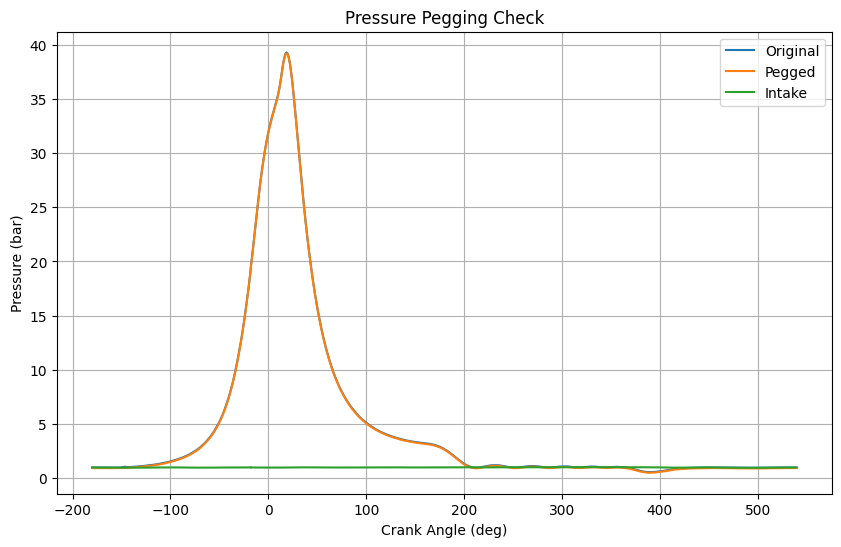

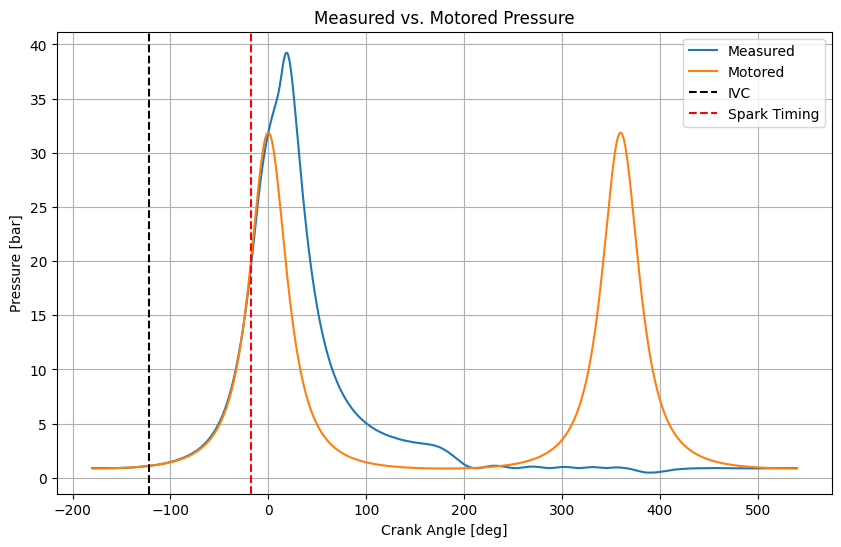

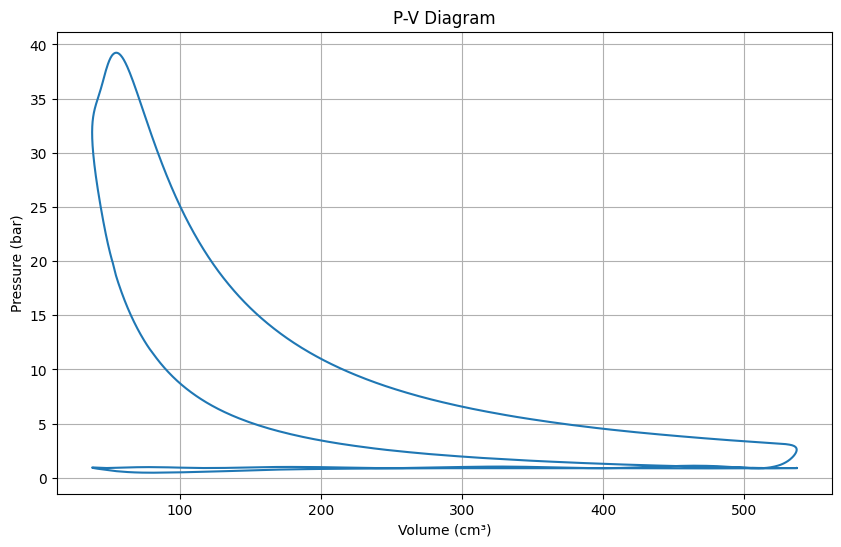

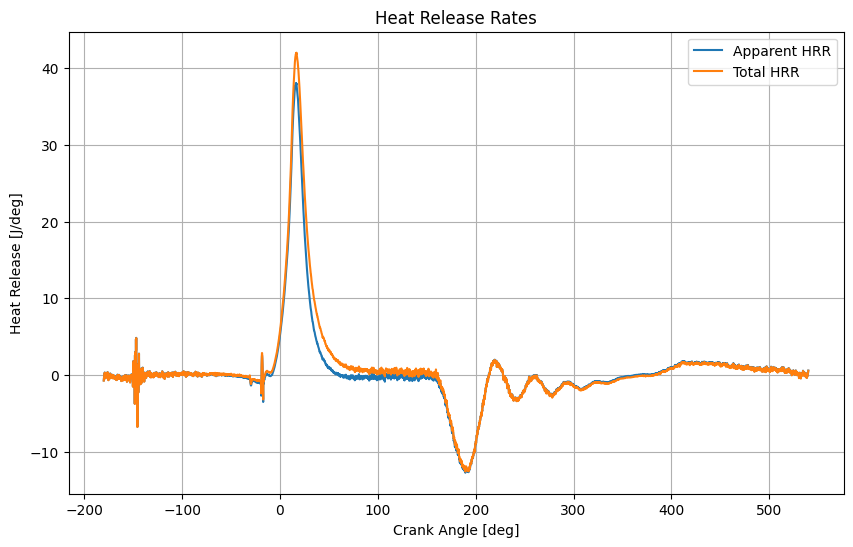

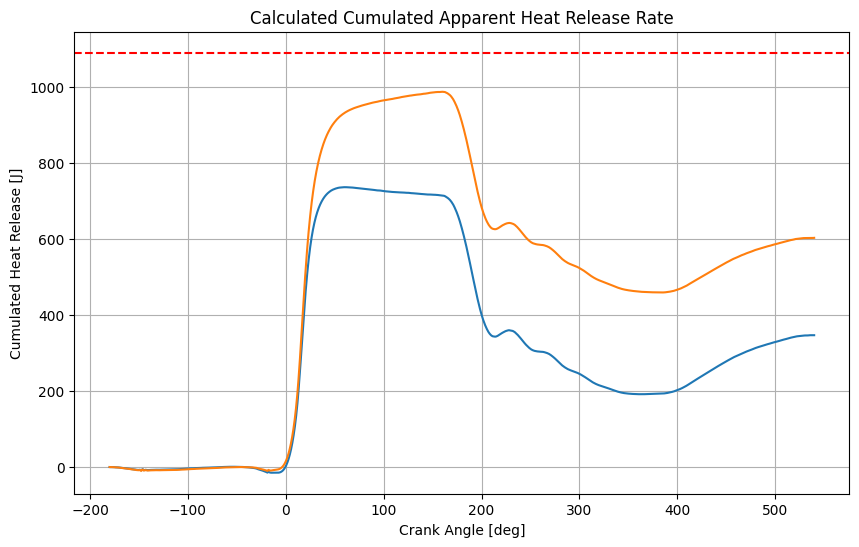

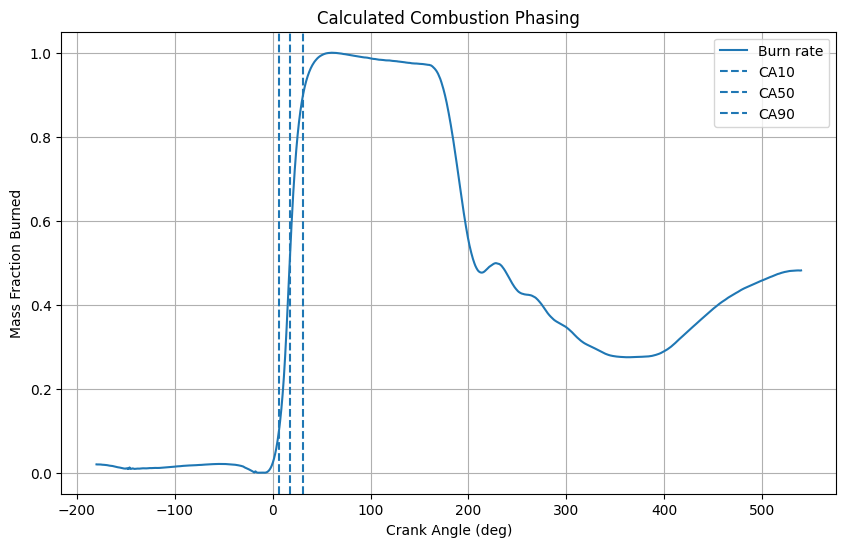

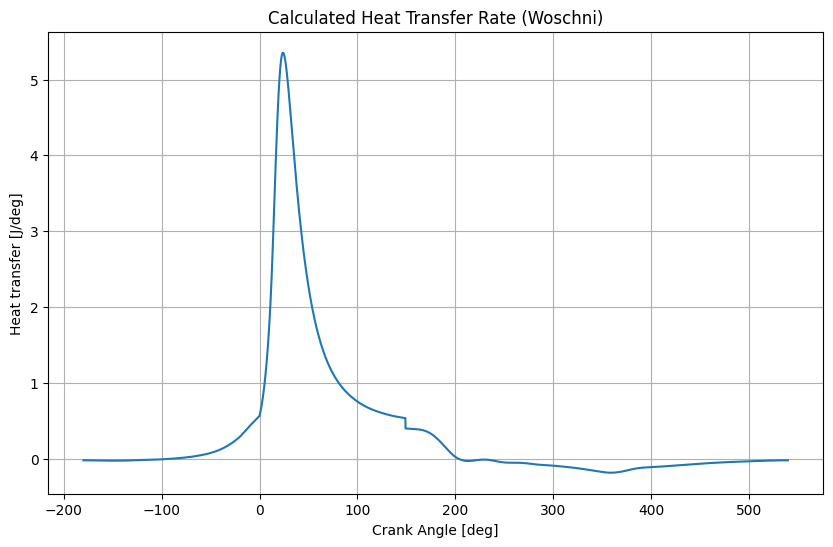

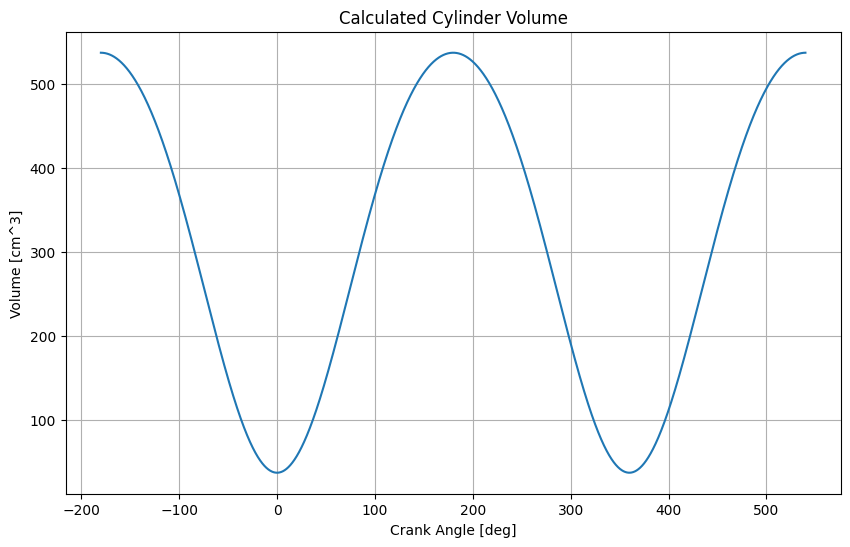

In [407]:
# ------------------------------------------------
# PLOTS
# ------------------------------------------------

# Original, pegged cylinder and intake manifold pressure profiles
plt.figure(figsize=(10,6))
plt.plot(theta, p_cyl/1e5, label="Original")
plt.plot(theta, p/1e5, label="Pegged")
plt.plot(theta, p_intake/1e5, label="Intake")
plt.xlabel("Crank Angle (deg)")
plt.ylabel("Pressure (bar)")
plt.title("Pressure Pegging Check")
plt.legend()
plt.grid()
plt.show()

# Measured and calculated motored pressure
plt.figure(figsize=(10,6))
plt.plot(theta,p/1e5,label="Measured")
plt.plot(theta,p_mot/1e5,label="Motored")
plt.axvline(IVC, linestyle="--", color="black", label="IVC")
plt.axvline(Spark_timing, linestyle="--", color="red", label="Spark Timing")
plt.xlabel("Crank Angle [deg]")
plt.ylabel("Pressure [bar]")
plt.title("Measured vs. Motored Pressure")
plt.legend()
plt.grid()
plt.show()

# p-V diagram
plt.figure(figsize=(10,6))
plt.plot(V*1e6, p/1e5)
plt.xlabel("Volume (cm³)")
plt.ylabel("Pressure (bar)")
plt.title("P-V Diagram")
plt.grid()
plt.show()

# Apparent and total heat release rate
plt.figure(figsize=(10,6))
plt.plot(theta,HRR_app,label="Apparent HRR")
plt.plot(theta,HRR_total,label="Total HRR")
plt.xlabel("Crank Angle [deg]")
plt.ylabel("Heat Release [J/deg]")
plt.title("Heat Release Rates")
plt.legend()
plt.grid()
plt.show()

# Cumulated heat release
plt.figure(figsize=(10,6))
plt.plot(theta,CHR,label="Cumulated Apparent HR")
plt.plot(theta,CHR_total,label="Cumulated Total HR")
plt.axhline(LHV_fuel*fuel_mass_cycle, linestyle="--", color="red", label="Fuel energy")
plt.xlabel("Crank Angle [deg]")
plt.ylabel("Cumulated Heat Release [J]")
plt.title("Calculated Cumulated Apparent Heat Release Rate")
plt.grid()
plt.show()

# Burn rate and combustion phasing
plt.figure(figsize=(10,6))
plt.plot(theta, CHR_norm, label="Burn rate")
plt.axvline(CA10, linestyle="--", label="CA10")
plt.axvline(CA50, linestyle="--", label="CA50")
plt.axvline(CA90, linestyle="--", label="CA90")
plt.xlabel("Crank Angle (deg)")
plt.ylabel("Mass Fraction Burned")
plt.title("Calculated Combustion Phasing")
plt.legend()
plt.grid()
plt.show()

# Heat transfer rate
plt.figure(figsize=(10,6))
plt.plot(theta,Qw)
plt.xlabel("Crank Angle [deg]")
plt.ylabel("Heat transfer [J/deg]")
plt.title("Calculated Heat Transfer Rate (Woschni)")
plt.grid()
plt.show()

# Volume
plt.figure(figsize=(10,6))
plt.plot(theta,V*1e6)
plt.xlabel("Crank Angle [deg]")
plt.ylabel("Volume [cm^3]")
plt.title("Calculated Cylinder Volume")
plt.grid()
plt.show()